In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [29]:
rhom = 3300.0 # Densidade de referência do manto
rhoc = 2700.0 # Densidade de referência da crosta
rhow = 1000.0 # Densidade da água

alpha = 3.28E-5 # Coeficiente de expansão volumétrico (1/K)
T1 = 1300.0 # Temperatura do manto astenosférico (oC)

hc = 35000.0 # Espessura original da crosta
a = 125000.0 # Espessura original da litosfera (crosta + manto lito.)

hca = hc/a
beta = 2.0

# Subsidência Inicial (Si)
Si = a*((rhom-rhoc)*hca*(1.0-(alpha*T1*hca/2))-rhom*alpha*T1/2)*(1.-1./beta)

Si /= rhom*(1.0-alpha*T1)-rhow

print("Subsidência inicial = %.2f m"%(Si))



Subsidência inicial = 2797.25 m


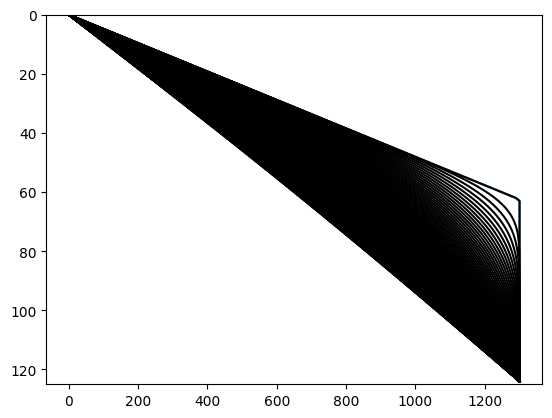

In [30]:
T1 = 1300.0 # Temperatura na base da litosfera
T0 = 0.0 # Temperatura na superfície

dz = 1000.0
z = np.arange(0.0,a,dz)

T = z*T1*beta/a
T[T>T1] = T1

plt.plot(T,z/1000)
plt.ylim(125,0)

kappa = 1.0E-6 # m2/s (Difusividade térmica)
t = 0.0
dt = 1000.0
t_print = 0.0
seg_por_ano = 365.*24.*60.*60.0
fac = dt*seg_por_ano*kappa/dz**2

fluxo_termico = []
tempo = []
subsidencia = []
k = 4.0 # W/(m.K) condutividade térmica

Toriginal = np.copy(T)

tmax = 160.0E6
for t in np.arange(0.0,tmax,dt):
  if t>=t_print:
    plt.plot(T,z/1000,"k")
    t_print+=1.0E6
    w = np.sum(rhom*(Toriginal-T)*alpha*dz)/(rhom-rhow)
    subsidencia = np.append(subsidencia,w)
    q = k*(T[1]-T[0])/dz # Fluxo térmico no instante t
    fluxo_termico = np.append(fluxo_termico,q) # vetor que guarda diferentes valores
    tempo = np.append(tempo,t)
  T[1:-1] += fac*(T[2:]-2*T[1:-1]+T[:-2])


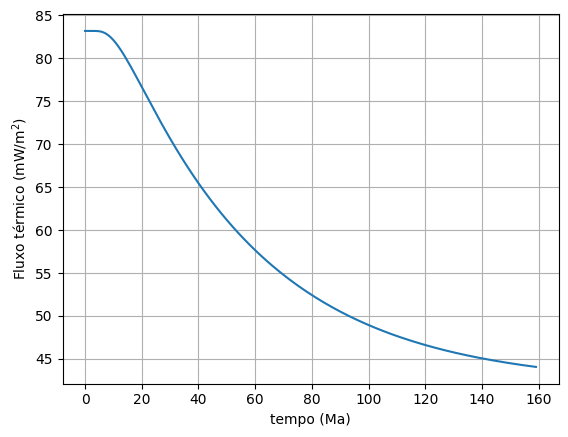

In [31]:
plt.plot(tempo/1.0E6,fluxo_termico*1000)
plt.xlabel("tempo (Ma)")
plt.ylabel("Fluxo térmico (mW/m$^2$)")
plt.grid()

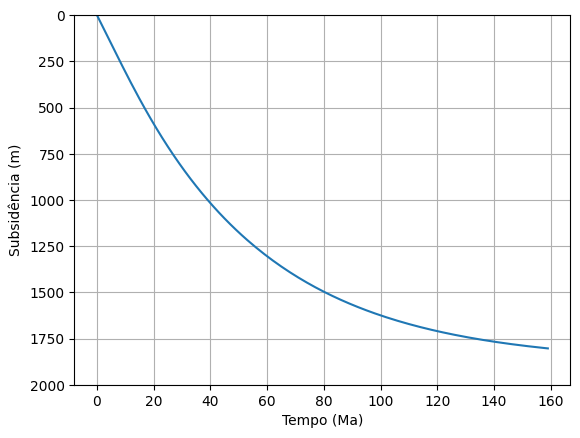

In [32]:
plt.plot(tempo/1.0E6,subsidencia)
plt.ylim(2000,0)
plt.ylabel("Subsidência (m)")
plt.xlabel("Tempo (Ma)")
plt.grid()